# Automated Failure Mode Classification in Rock Mechanics

When a rock sample is crushed in a laboratory test, the way it breaks is recorded as a failure mode code - for example, 2B means a shear fracture at a specific angle, and XA means the sample broke along an existing crack. These codes are currently assigned by a person looking at the broken sample, which takes time and can vary between observers.

This project trains a machine learning model to predict the failure mode code from measurements already recorded during the test, such as the size of the sample, how much pressure was applied, and how stiff the rock was. If the model can do this reliably, it could speed up analysis and make the results more consistent.

The data comes from two types of laboratory tests: uniaxial compression (the sample is squeezed from top and bottom with no side pressure, about 177 samples) and triaxial compression (side pressure is added to simulate conditions deep underground, about 351 samples). A third test type in the raw data, the Brazilian tensile test, does not have failure mode codes and is not used for classification. A fourth dataset covering rock mass field observations is also excluded because it describes the rock at a tunnel or mine face, not individual laboratory samples.

Three classification methods are tested: Logistic Regression, Random Forest, and Support Vector Machine. The best one is tuned further, and the results are explained using a tool called SHAP, which shows which measurements had the most influence on each prediction.

## Section 1 - Libraries

This cell loads all the tools (called libraries) that are used throughout the notebook. Loading everything in one place at the start means the notebook will raise an error immediately if something is missing, rather than failing halfway through a later step. The version numbers are printed so that anyone trying to reproduce the results knows exactly which software was used.

In [2]:
# Install any missing libraries automatically before importing them.
# This means the notebook can run on any computer without manual setup steps.
import subprocess, sys

required = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "shap",
    "xlrd",
]

for package in required:
    try:
        __import__(package if package != "scikit-learn" else "sklearn")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
        print(f"{package} installed.")

print("All libraries ready.")

# ----- Imports -----

import warnings
warnings.filterwarnings("ignore")

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Interpretability
import shap

# Reproducibility - fixing the random seed means results are the same every time the notebook is run
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

# Print version numbers so results can be reproduced on another machine
print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"matplotlib   {matplotlib.__version__}")
print(f"seaborn      {sns.__version__}")
import sklearn; print(f"scikit-learn {sklearn.__version__}")
print(f"shap         {shap.__version__}")

Installing shap...
shap installed.
Installing xlrd...
xlrd installed.
All libraries ready.
numpy        1.26.4
pandas       2.2.3
matplotlib   3.9.2
seaborn      0.13.2
scikit-learn 1.5.1
shap         0.51.0


## Section 2 - Data Ingestion

This section loads the four raw Excel files into Python. Each file has several rows at the top that describe the columns rather than containing actual measurements, so the column names are assigned manually after loading. No changes are made to the data itself here - the goal is only to get it into a form that can be inspected in the next section.

Two of the four files are loaded for reference but are not used in the classifier:
- Brazilian tensile test data does not have failure mode codes, only a tensile strength value in MPa.
- Rock mass rating data describes observations at a mine face, not individual laboratory samples.

The two files used for classification are the uniaxial compression test (UCM) and the triaxial compression test (TCM).

In [3]:
import os

RAW_DIR = os.path.join("data", "raw")

# --- Triaxial compression test (TCM) ---
# Data starts at row 10 (rows 0-9 are headers and units)
# Column names are assigned manually based on inspection of the original file
TCM_COLS = [
    "specimen_id", "hole_id", "sample_id", "depth_top_m", "rock_type",
    "diameter_mm", "height_mm", "hd_ratio", "mass_g", "density_gcm3",
    "confining_pressure_mpa", "failure_load_kn", "tcm_strength_mpa",
    "tangent_modulus_gpa", "secant_modulus_gpa",
    "tangent_poisson", "secant_poisson",
    "axial_strain_at_failure", "failure_mode", "note"
]

df_tcm_raw = pd.read_excel(
    os.path.join(RAW_DIR, "Combined Triaxial test results.xls"),
    sheet_name="TCM",
    header=None,
    skiprows=10,
    names=TCM_COLS,
    engine="xlrd"
)
print(f"TCM raw shape: {df_tcm_raw.shape}")
print(df_tcm_raw.head(3).to_string())
print()

# --- Uniaxial compression test (UCM) ---
# Data starts at row 9
UCM_COLS = [
    "specimen_id", "hole_id", "sample_id", "depth_m", "rock_type",
    "diameter_mm", "height_mm", "hd_ratio", "mass_g", "density_gcm3",
    "failure_load_kn", "ucs_mpa",
    "tangent_modulus_gpa", "secant_modulus_gpa",
    "tangent_poisson", "secant_poisson",
    "axial_strain_at_failure", "failure_code", "note"
]

df_ucm_raw = pd.read_excel(
    os.path.join(RAW_DIR, "Combined Uniaxial Test Results.xls"),
    sheet_name="UCM",
    header=None,
    skiprows=9,
    names=UCM_COLS,
    engine="xlrd"
)
print(f"UCM raw shape: {df_ucm_raw.shape}")
print(df_ucm_raw.head(3).to_string())
print()

# --- Brazilian tensile test (UTB) - loaded for reference only, not used in classifier ---
UTB_COLS = [
    "specimen_id", "hole_id", "sample_id", "depth_m", "rock_type",
    "diameter_mm", "height_mm", "mass_g", "density_gcm3",
    "failure_load_kn", "bts_mpa", "note", "empty1", "empty2", "empty3"
]

df_utb_raw = pd.read_excel(
    os.path.join(RAW_DIR, "Combined BrazilianTest Results.xls"),
    sheet_name="UTB",
    header=None,
    skiprows=9,
    names=UTB_COLS,
    engine="xlrd"
)
print(f"UTB raw shape (reference only - no failure mode codes): {df_utb_raw.shape}")
print()

# --- Rock mass rating (RMR) - loaded for reference only, not used in classifier ---
df_rmr_raw = pd.read_excel(
    os.path.join(RAW_DIR, "Rock Mass Rating data sheet.xls"),
    sheet_name=0,
    header=0,
    engine="xlrd"
)
print(f"RMR raw shape (reference only - field mapping data): {df_rmr_raw.shape}")

TCM raw shape: (351, 20)
  specimen_id hole_id sample_id  depth_top_m rock_type  diameter_mm height_mm  hd_ratio  mass_g  density_gcm3  confining_pressure_mpa  failure_load_kn  tcm_strength_mpa  tangent_modulus_gpa  secant_modulus_gpa  tangent_poisson  secant_poisson  axial_strain_at_failure failure_mode  note
0  TCM-1-F-01     NaN       NaN          NaN       NaN        47.27     94.61  2.001481  542.56      3.267756                     5.0            484.5        276.078569                153.0               152.0            0.236           0.216                 0.001802           2B   NaN
1  TCM-1-F-02     NaN       NaN          NaN       NaN        47.24     96.05  2.033235  550.46      3.269782                    10.0            652.9        372.509205                149.0               156.0            0.232           0.257                 0.002646           XA   NaN
2  TCM-1-F-03     NaN       NaN          NaN       NaN        47.17     91.77  1.945516  525.08      3.274184     

## Section 3 - Data Inspection

Before cleaning anything, it helps to look at the raw data and record what problems exist. This section checks the size of each dataset, which columns have missing values, and what the failure mode labels actually look like. Making these observations first means the cleaning steps in Section 4 are based on what is actually in the data, not on assumptions.

Only the two classification datasets (TCM and UCM) are inspected in detail.

In [5]:
def inspect(df, name, target_col):
    sep = "=" * 60
    print(sep)
    print(name + "  -  " + str(df.shape[0]) + " rows, " + str(df.shape[1]) + " columns")
    print(sep)

    print("Column types and null counts:")
    summary = pd.DataFrame({
        "dtype":  df.dtypes,
        "nulls":  df.isnull().sum(),
        "null_%": (df.isnull().mean() * 100).round(1)
    })
    print(summary.to_string())

    print("Unique values in target column [" + target_col + "]:")
    print(df[target_col].value_counts(dropna=False).to_string())

    print("Unique values in [rock_type]:")
    print(df["rock_type"].value_counts(dropna=False).to_string())
    print()

inspect(df_tcm_raw, "Triaxial (TCM)", "failure_mode")
inspect(df_ucm_raw, "Uniaxial (UCM)", "failure_code")


Triaxial (TCM)  -  351 rows, 20 columns
Column types and null counts:
                           dtype  nulls  null_%
specimen_id               object     37    10.5
hole_id                   object    317    90.3
sample_id                 object    318    90.6
depth_top_m              float64    325    92.6
rock_type                 object    289    82.3
diameter_mm              float64     35    10.0
height_mm                 object     34     9.7
hd_ratio                 float64     35    10.0
mass_g                   float64     35    10.0
density_gcm3             float64     35    10.0
confining_pressure_mpa   float64     35    10.0
failure_load_kn          float64     35    10.0
tcm_strength_mpa         float64     35    10.0
tangent_modulus_gpa      float64     35    10.0
secant_modulus_gpa       float64     35    10.0
tangent_poisson          float64     35    10.0
secant_poisson           float64     35    10.0
axial_strain_at_failure  float64     35    10.0
failure_mode      

## Section 4 - Data Cleaning

The inspection in Section 3 revealed several problems that need to be fixed before the data can be used for modelling:

- The rock type name is spread across multiple rows in the original file because of how Excel merges cells. For example, "Footwall" appears in one row and "Pyroxenite" in the next. The fix is to forward-fill: each empty rock type cell inherits the value from the row above it, then adjacent partial names are joined.
- Some rows at the bottom of each sheet contain summary statistics (average, standard deviation, coefficient of variation) rather than specimen measurements. These are removed.
- The target columns (failure_mode and failure_code) have leading or trailing spaces in some entries, for example " 4B" instead of "4B". These are stripped.
- Rows with no failure mode label cannot be used for training and are removed.
- The columns for hole ID, sample ID, depth, and notes are mostly empty and carry no information useful to the classifier. They are dropped.
- Two columns were read as text instead of numbers due to mixed content in the original file. These are converted to numeric values.

A cleaning function is written once and applied to both datasets to keep the steps consistent.

In [6]:
JUNK_LABELS = {"average", "standard deviation", "coefficient of variance",
               "coefficient of  variation", "coefficient of variation"}

def clean_dataset(df, target_col, numeric_cols):
    df = df.copy()

    # Drop columns that are not useful for classification
    drop_cols = [c for c in ["note", "hole_id", "sample_id", "depth_top_m", "depth_m"] if c in df.columns]
    df = df.drop(columns=drop_cols)

    # Remove statistical summary rows mixed in with specimen data
    mask_junk = df["specimen_id"].str.strip().str.lower().isin(JUNK_LABELS)
    df = df[~mask_junk]

    # Forward-fill rock_type to fix split-row values from merged Excel cells
    # Then join adjacent partial names (e.g. "Footwall" + "Pyroxenite" -> "Footwall Pyroxenite")
    df["rock_type"] = df["rock_type"].ffill()

    # Standardise rock type names by stripping whitespace
    df["rock_type"] = df["rock_type"].str.strip()

    # Map partial names to full standardised names
    rock_map = {
        "Footwall":    "Footwall Pyroxenite",
        "Hanginwall":  "Hangingwall Pyroxenite",
        "Hangingwall": "Hangingwall Pyroxenite",
        "Gabbro":      "Gabbro Norite",
        "Norite":      "Gabbro Norite",
        "Pyroxenite":  "Footwall Pyroxenite",
        "Reef":        "Reef",
        "Footwall Pyroxenite":    "Footwall Pyroxenite",
        "Hangingwall Pyroxenite": "Hangingwall Pyroxenite",
        "Gabbro Norite":          "Gabbro Norite",
    }
    df["rock_type"] = df["rock_type"].map(rock_map)

    # Strip whitespace from the target label column
    df[target_col] = df[target_col].astype(str).str.strip()

    # Drop rows where the target label is missing or unreadable
    df = df[~df[target_col].isin(["nan", "", "NaN"])]
    df = df.dropna(subset=[target_col])

    # Convert columns that should be numeric but were read as text
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Drop rows that still have missing values in key measurement columns
    df = df.dropna(subset=[c for c in numeric_cols if c in df.columns])

    df = df.reset_index(drop=True)
    return df


TCM_NUMERIC = [
    "diameter_mm", "height_mm", "hd_ratio", "mass_g", "density_gcm3",
    "confining_pressure_mpa", "failure_load_kn", "tcm_strength_mpa",
    "tangent_modulus_gpa", "secant_modulus_gpa",
    "tangent_poisson", "secant_poisson", "axial_strain_at_failure"
]

UCM_NUMERIC = [
    "diameter_mm", "height_mm", "hd_ratio", "mass_g", "density_gcm3",
    "failure_load_kn", "ucs_mpa",
    "tangent_modulus_gpa", "secant_modulus_gpa",
    "tangent_poisson", "secant_poisson", "axial_strain_at_failure"
]

df_tcm = clean_dataset(df_tcm_raw, "failure_mode", TCM_NUMERIC)
df_ucm = clean_dataset(df_ucm_raw, "failure_code", UCM_NUMERIC)

print("TCM after cleaning:", df_tcm.shape)
print("failure_mode values:")
print(df_tcm["failure_mode"].value_counts().to_string())
print("rock_type values:")
print(df_tcm["rock_type"].value_counts(dropna=False).to_string())
print()
print("UCM after cleaning:", df_ucm.shape)
print("failure_code values:")
print(df_ucm["failure_code"].value_counts().to_string())
print("rock_type values:")
print(df_ucm["rock_type"].value_counts(dropna=False).to_string())

TCM after cleaning: (313, 16)
failure_mode values:
failure_mode
XA    269
3B     17
2B     10
4B     10
1B      2
5B      2
6B      1
7B      1
0B      1
rock_type values:
rock_type
Footwall Pyroxenite       148
Gabbro Norite              80
Reef                       74
Hangingwall Pyroxenite      8
NaN                         3

UCM after cleaning: (138, 15)
failure_code values:
failure_code
YA    86
XA    30
4B    10
3B     8
2B     3
1B     1
rock_type values:
rock_type
Footwall Pyroxenite       65
Gabbro Norite             39
Reef                      24
Hangingwall Pyroxenite     9
NaN                        1


## Section 5 - Exploratory Data Analysis

Before building a model, it is useful to look at the data visually. This section answers four questions:

1. How many specimens belong to each failure mode class? If some classes have very few examples, the model may struggle to learn them.
2. How are the measurement values distributed? Unusual distributions or extreme outliers can affect model performance.
3. Are any measurements strongly correlated with each other? Highly correlated features carry overlapping information.
4. Does the failure mode vary by rock type? If certain failure modes only occur in one rock type, rock type may be an important feature.

No changes are made to the data here. The findings inform decisions in Sections 6 and 9.

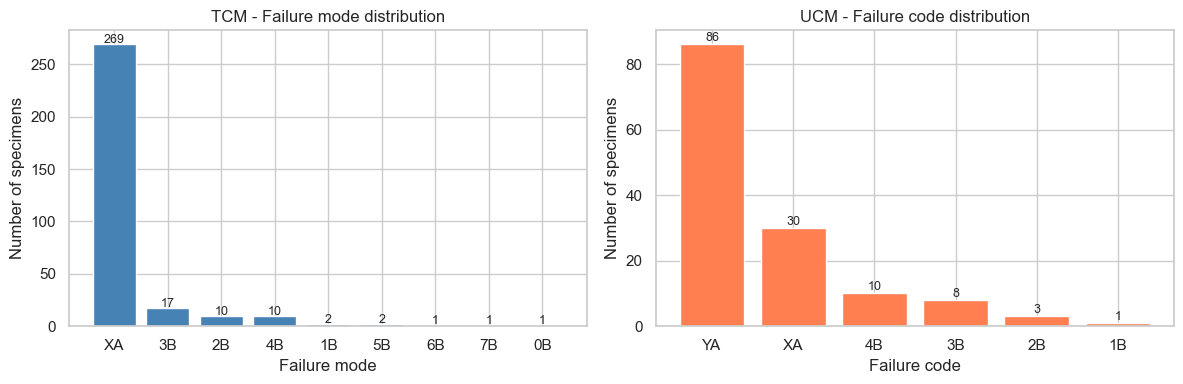

TCM class imbalance: XA accounts for 85.9 % of specimens
UCM class imbalance: YA accounts for 62.3 % of specimens



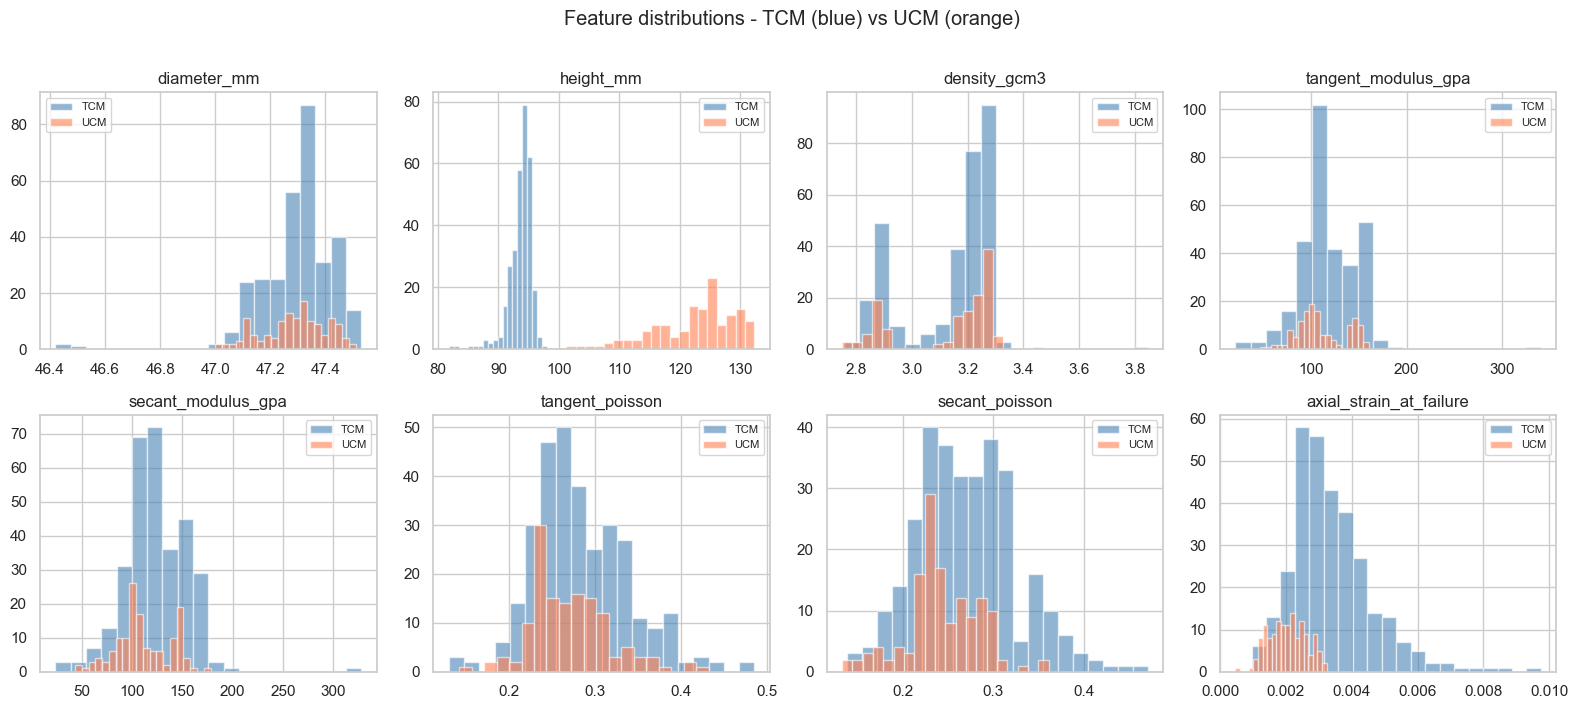

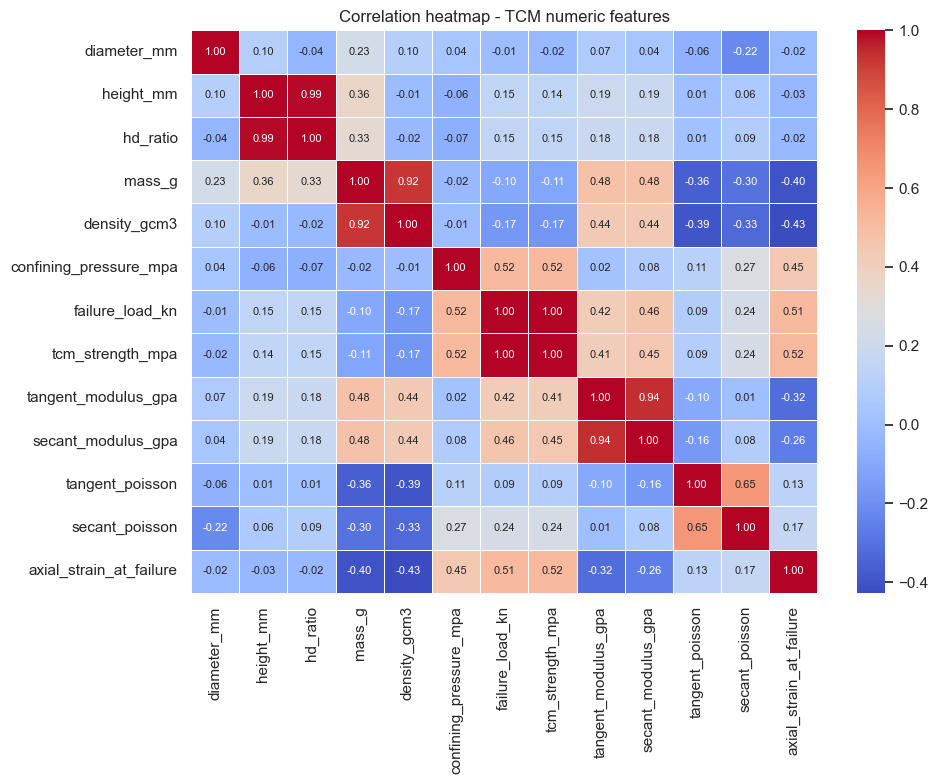

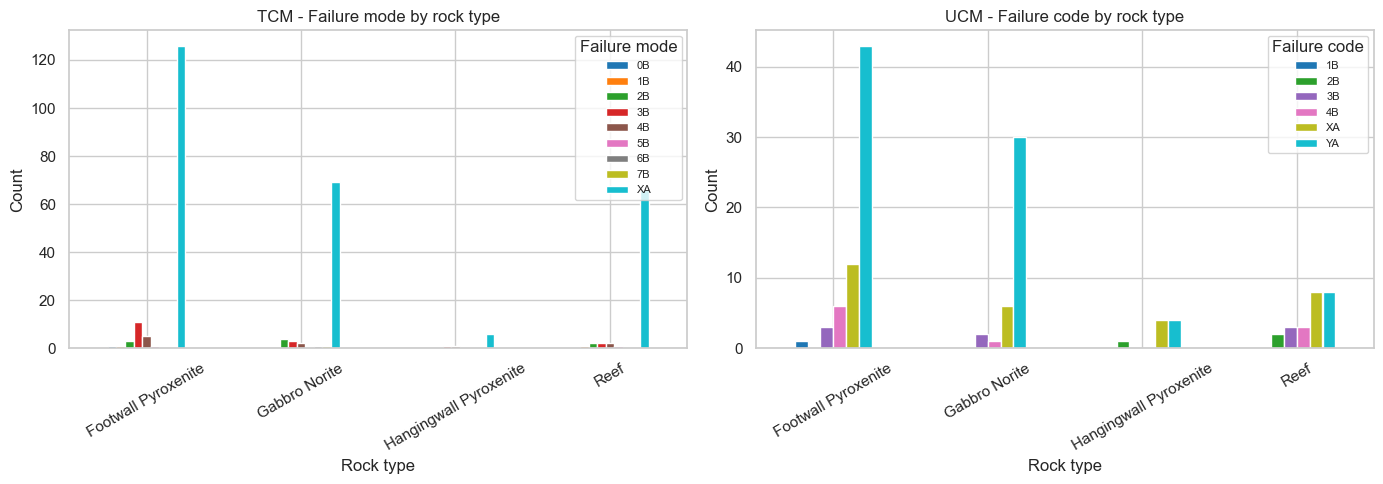

In [7]:
# --- 1. Class distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tcm_counts = df_tcm["failure_mode"].value_counts()
ucm_counts = df_ucm["failure_code"].value_counts()

axes[0].bar(tcm_counts.index, tcm_counts.values, color="steelblue")
axes[0].set_title("TCM - Failure mode distribution")
axes[0].set_xlabel("Failure mode")
axes[0].set_ylabel("Number of specimens")
for i, v in enumerate(tcm_counts.values):
    axes[0].text(i, v + 1, str(v), ha="center", fontsize=9)

axes[1].bar(ucm_counts.index, ucm_counts.values, color="coral")
axes[1].set_title("UCM - Failure code distribution")
axes[1].set_xlabel("Failure code")
axes[1].set_ylabel("Number of specimens")
for i, v in enumerate(ucm_counts.values):
    axes[1].text(i, v + 1, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("TCM class imbalance: XA accounts for",
      round(tcm_counts["XA"] / tcm_counts.sum() * 100, 1), "% of specimens")
print("UCM class imbalance: YA accounts for",
      round(ucm_counts["YA"] / ucm_counts.sum() * 100, 1), "% of specimens")
print()

# --- 2. Feature distributions ---
shared_features = [
    "diameter_mm", "height_mm", "density_gcm3",
    "tangent_modulus_gpa", "secant_modulus_gpa",
    "tangent_poisson", "secant_poisson", "axial_strain_at_failure"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(shared_features):
    if col in df_tcm.columns:
        axes[i].hist(df_tcm[col].dropna(), bins=20, alpha=0.6, label="TCM", color="steelblue")
    if col in df_ucm.columns:
        axes[i].hist(df_ucm[col].dropna(), bins=20, alpha=0.6, label="UCM", color="coral")
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle("Feature distributions - TCM (blue) vs UCM (orange)", y=1.01)
plt.tight_layout()
plt.show()

# --- 3. Correlation heatmap (TCM only - it has the most features) ---
tcm_numeric = df_tcm.select_dtypes(include="number")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(tcm_numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation heatmap - TCM numeric features")
plt.tight_layout()
plt.show()

# --- 4. Failure mode by rock type ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tcm_cross = pd.crosstab(df_tcm["rock_type"], df_tcm["failure_mode"])
tcm_cross.plot(kind="bar", ax=axes[0], colormap="tab10")
axes[0].set_title("TCM - Failure mode by rock type")
axes[0].set_xlabel("Rock type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Failure mode", fontsize=8)

ucm_cross = pd.crosstab(df_ucm["rock_type"], df_ucm["failure_code"])
ucm_cross.plot(kind="bar", ax=axes[1], colormap="tab10")
axes[1].set_title("UCM - Failure code by rock type")
axes[1].set_xlabel("Rock type")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Failure code", fontsize=8)

plt.tight_layout()
plt.show()

### Observations from Exploratory Analysis

**Class imbalance is the most significant finding.** In the triaxial dataset, XA accounts for 85.9% of all labelled specimens. In the uniaxial dataset, YA accounts for 62.3%. This means a model that simply predicts XA or YA for every specimen would appear highly accurate without having learned anything useful. All models in Section 9 will use class weighting to counteract this.

**Several features carry duplicate information.** The tangent and secant modulus values correlate at 0.94, the height-to-diameter ratio correlates with height at 0.99 (because specimen diameter is nearly constant at 47mm across all tests), and in the triaxial dataset, compressive strength is derived directly from failure load - they correlate at 1.00. Removing the redundant columns in Section 6 reduces noise without losing information.

**The two test types produce different specimen dimensions.** Triaxial specimens are shorter (around 94mm height) while uniaxial specimens are taller (112-132mm). This difference is by design - the two test standards require different height-to-diameter ratios. A test_type column added in Section 6 allows the model to account for this.

**Hangingwall Pyroxenite is underrepresented.** This rock type has very few specimens in both datasets. The model will have limited data to learn its failure behaviour, and performance on this rock type is expected to be weaker than on others.

## Section 6 - Feature Engineering

This section prepares the final set of features that will be used for modelling. Three things happen here:

**Removing redundant columns.** The correlation heatmap in Section 5 showed that some columns carry the same information as others. Keeping both would not add information but would add noise. The pairs removed are:
- hd_ratio is dropped because it is almost perfectly correlated with height_mm (the diameter is nearly identical across all specimens, so the ratio and the height are essentially the same number).
- tcm_strength_mpa is dropped from TCM because it is derived directly from failure_load_kn using the specimen cross-section area - they are mathematically equivalent.

**Adding derived features.** Two new columns are calculated from existing measurements:
- slenderness_ratio = height divided by diameter. This describes the shape of the specimen and is known in rock mechanics to influence how a specimen breaks.
- modulus_ratio = tangent modulus divided by secant modulus. A ratio close to 1 means the rock behaves similarly at low and high stress levels. A larger ratio suggests the rock stiffens or softens under load.

**Combining the two datasets.** UCM and TCM data are merged into one table. A test_type column is added to record which test each specimen came from, since the two tests differ in whether confining pressure was applied. The target column is standardised to failure_mode across both. Rows with no rock type recorded are removed. The combined dataset is saved to data/processed/combined_dataset.csv.

In [9]:
import os
PROCESSED_DIR = os.path.join('data', 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

# --- TCM feature engineering ---
tcm = df_tcm.copy()
tcm = tcm.drop(columns=['hd_ratio', 'tcm_strength_mpa'], errors='ignore')
tcm['slenderness_ratio'] = tcm['height_mm'] / tcm['diameter_mm']
tcm['modulus_ratio']     = tcm['tangent_modulus_gpa'] / tcm['secant_modulus_gpa']
tcm['test_type']         = 'TCM'

# --- UCM feature engineering ---
ucm = df_ucm.copy()
ucm = ucm.drop(columns=['hd_ratio', 'ucs_mpa'], errors='ignore')
ucm['slenderness_ratio']      = ucm['height_mm'] / ucm['diameter_mm']
ucm['modulus_ratio']          = ucm['tangent_modulus_gpa'] / ucm['secant_modulus_gpa']
ucm['test_type']              = 'UCM'
ucm['confining_pressure_mpa'] = 0.0

# Rename target column to match TCM
ucm = ucm.rename(columns={'failure_code': 'failure_mode'})

# --- Combine ---
shared_cols = [
    'specimen_id', 'rock_type', 'test_type',
    'diameter_mm', 'height_mm', 'mass_g', 'density_gcm3',
    'confining_pressure_mpa', 'failure_load_kn',
    'tangent_modulus_gpa', 'secant_modulus_gpa',
    'tangent_poisson', 'secant_poisson',
    'axial_strain_at_failure',
    'slenderness_ratio', 'modulus_ratio',
    'failure_mode'
]

combined = pd.concat(
    [tcm[shared_cols], ucm[shared_cols]],
    ignore_index=True
)

# Drop the few rows where rock_type is still missing
combined = combined.dropna(subset=['rock_type'])
combined = combined.reset_index(drop=True)

# Save
combined.to_csv(os.path.join(PROCESSED_DIR, 'combined_dataset.csv'), index=False)

print('Combined dataset shape:', combined.shape)
print()
print('Failure mode distribution:')
print(combined['failure_mode'].value_counts().to_string())
print()
print('Test type distribution:')
print(combined['test_type'].value_counts().to_string())
print()
print('Rock type distribution:')
print(combined['rock_type'].value_counts().to_string())
print()
print('Columns:', list(combined.columns))
print()
print('Null counts:')
print(combined.isnull().sum().to_string())


Combined dataset shape: (447, 17)

Failure mode distribution:
failure_mode
XA    297
YA     85
3B     25
4B     20
2B     12
1B      3
5B      2
6B      1
7B      1
0B      1

Test type distribution:
test_type
TCM    310
UCM    137

Rock type distribution:
rock_type
Footwall Pyroxenite       213
Gabbro Norite             119
Reef                       98
Hangingwall Pyroxenite     17

Columns: ['specimen_id', 'rock_type', 'test_type', 'diameter_mm', 'height_mm', 'mass_g', 'density_gcm3', 'confining_pressure_mpa', 'failure_load_kn', 'tangent_modulus_gpa', 'secant_modulus_gpa', 'tangent_poisson', 'secant_poisson', 'axial_strain_at_failure', 'slenderness_ratio', 'modulus_ratio', 'failure_mode']

Null counts:
specimen_id                0
rock_type                  0
test_type                  0
diameter_mm                0
height_mm                  0
mass_g                     0
density_gcm3               0
confining_pressure_mpa     0
failure_load_kn            0
tangent_modulus_gpa     

## Section 7 - Dataset Split

Before the data is split into training and test sets, four rare failure mode classes are removed: 0B, 5B, 6B, and 7B. Each of these has fewer than 5 specimens in the combined dataset. A model cannot learn a meaningful pattern from so few examples, and including them would produce misleading results - any prediction on these classes would essentially be a guess. These classes are noted as a limitation in the conclusions.

After removing rare classes, the remaining data is split into a training set (80%) and a test set (20%). The split is stratified by failure mode, which means each class appears in the same proportion in both sets. This matters here because the classes are imbalanced - without stratification, a small class could end up entirely in one set by chance.

The test set is set aside here and not used again until Section 12. All model training and tuning in Sections 9 and 10 uses only the training set.

In [10]:
# Remove failure mode classes with fewer than 5 specimens
min_samples = 5
class_counts = combined['failure_mode'].value_counts()
valid_classes = class_counts[class_counts >= min_samples].index.tolist()
rare_classes  = class_counts[class_counts <  min_samples].index.tolist()

print('Classes kept:', sorted(valid_classes))
print('Classes dropped (too few specimens):', sorted(rare_classes))
print()

df_model = combined[combined['failure_mode'].isin(valid_classes)].copy()
df_model = df_model.reset_index(drop=True)
print('Dataset size after removing rare classes:', df_model.shape)
print()
print('Class distribution after filtering:')
print(df_model['failure_mode'].value_counts().to_string())
print()

# Define features and target
# specimen_id is an identifier, not a measurement - excluded from features
FEATURE_COLS = [
    'diameter_mm', 'height_mm', 'mass_g', 'density_gcm3',
    'confining_pressure_mpa', 'failure_load_kn',
    'tangent_modulus_gpa', 'secant_modulus_gpa',
    'tangent_poisson', 'secant_poisson',
    'axial_strain_at_failure', 'slenderness_ratio', 'modulus_ratio',
    'rock_type', 'test_type'
]
TARGET_COL = 'failure_mode'

X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print('Training set size:', X_train.shape[0])
print('Test set size:    ', X_test.shape[0])
print()
print('Class distribution in training set:')
print(y_train.value_counts().to_string())
print()
print('Class distribution in test set:')
print(y_test.value_counts().to_string())


Classes kept: ['2B', '3B', '4B', 'XA', 'YA']
Classes dropped (too few specimens): ['0B', '1B', '5B', '6B', '7B']

Dataset size after removing rare classes: (439, 17)

Class distribution after filtering:
failure_mode
XA    297
YA     85
3B     25
4B     20
2B     12

Training set size: 351
Test set size:     88

Class distribution in training set:
failure_mode
XA    237
YA     68
3B     20
4B     16
2B     10

Class distribution in test set:
failure_mode
XA    60
YA    17
3B     5
4B     4
2B     2


## Section 8 - Preprocessing

Machine learning models work with numbers, not text. Two columns in the dataset - rock_type and test_type - contain text categories. These are converted into a set of 0/1 columns using one-hot encoding. For example, rock_type becomes four separate columns (one per rock type), where a 1 means the specimen belongs to that rock type and 0 means it does not.

The numeric features are also on very different scales. For example, failure_load_kn ranges into the hundreds while axial_strain_at_failure is a small decimal around 0.002. Some models (particularly Logistic Regression and SVM) are sensitive to this and will pay more attention to large-valued features simply because the numbers are bigger. Scaling adjusts all numeric columns to have a mean of zero and a standard deviation of one, removing this bias.

Both the encoder and the scaler are fitted using only the training set. The same fitted encoder and scaler are then applied to the test set. This is important: if the test set were used to fit the scaler, the model would have indirectly seen test data during preparation, which would make the final evaluation results overoptimistic.

In [11]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

NUMERIC_COLS = [
    'diameter_mm', 'height_mm', 'mass_g', 'density_gcm3',
    'confining_pressure_mpa', 'failure_load_kn',
    'tangent_modulus_gpa', 'secant_modulus_gpa',
    'tangent_poisson', 'secant_poisson',
    'axial_strain_at_failure', 'slenderness_ratio', 'modulus_ratio'
]
CATEGORICAL_COLS = ['rock_type', 'test_type']

# Build a preprocessor that scales numeric columns and one-hot encodes categorical columns
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERIC_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_COLS)
])

# Encode the target labels as integers (required by some sklearn models)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# Fit on training data only, then transform both sets
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Get final feature names for use in SHAP later
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_COLS)
all_feature_names = NUMERIC_COLS + list(ohe_feature_names)

print('Training set shape after preprocessing:', X_train_proc.shape)
print('Test set shape after preprocessing:    ', X_test_proc.shape)
print()
print('Class label mapping (integer -> failure mode):')
for i, label in enumerate(le.classes_):
    print(' ', i, '->', label)
print()
print('Feature names after encoding:')
print(all_feature_names)


Training set shape after preprocessing: (351, 19)
Test set shape after preprocessing:     (88, 19)

Class label mapping (integer -> failure mode):
  0 -> 2B
  1 -> 3B
  2 -> 4B
  3 -> XA
  4 -> YA

Feature names after encoding:
['diameter_mm', 'height_mm', 'mass_g', 'density_gcm3', 'confining_pressure_mpa', 'failure_load_kn', 'tangent_modulus_gpa', 'secant_modulus_gpa', 'tangent_poisson', 'secant_poisson', 'axial_strain_at_failure', 'slenderness_ratio', 'modulus_ratio', 'rock_type_Footwall Pyroxenite', 'rock_type_Gabbro Norite', 'rock_type_Hangingwall Pyroxenite', 'rock_type_Reef', 'test_type_TCM', 'test_type_UCM']


## Section 9 - Baseline Models

Three classification models are trained here and compared using cross-validation.

**Logistic Regression** draws a straight-line boundary between classes in the feature space. It is simple, fast, and easy to interpret. It serves as the baseline that more complex models should beat.

**Random Forest** builds a large number of decision trees, each trained on a random subset of the data, and combines their predictions. It handles non-linear relationships between features and is generally robust to outliers.

**Support Vector Machine (SVM)** finds the boundary between classes that maximises the gap between the nearest points of each class. It tends to perform well on small datasets.

All three models use class_weight='balanced', which automatically adjusts the model's attention to each class based on how many specimens it has. Without this, the model would focus almost entirely on XA and YA and ignore the smaller classes.

Each model is evaluated using 5-fold stratified cross-validation on the training set. This means the training set is split into 5 equal parts; the model is trained on 4 parts and tested on the remaining 1, repeated 5 times. The average score across all 5 rounds gives a more reliable estimate of performance than a single train/test split would. The test set from Section 7 is not used here.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=RANDOM_STATE
    ),
    'SVM': SVC(
        class_weight='balanced', kernel='rbf', probability=True, random_state=RANDOM_STATE
    ),
}

cv_results = {}

for name, model in models.items():
    scores = cross_validate(
        model, X_train_proc, y_train_enc,
        cv=cv,
        scoring=['accuracy', 'f1_weighted'],
        return_train_score=False
    )
    cv_results[name] = {
        'accuracy_mean': scores['test_accuracy'].mean(),
        'accuracy_std':  scores['test_accuracy'].std(),
        'f1_mean':       scores['test_f1_weighted'].mean(),
        'f1_std':        scores['test_f1_weighted'].std(),
    }
    print(name)
    print('  Accuracy : {:.3f} +/- {:.3f}'.format(
        cv_results[name]['accuracy_mean'], cv_results[name]['accuracy_std']))
    print('  F1 (wtd) : {:.3f} +/- {:.3f}'.format(
        cv_results[name]['f1_mean'], cv_results[name]['f1_std']))
    print()


Logistic Regression
  Accuracy : 0.618 +/- 0.067
  F1 (wtd) : 0.669 +/- 0.062

Random Forest
  Accuracy : 0.809 +/- 0.027
  F1 (wtd) : 0.766 +/- 0.017

SVM
  Accuracy : 0.681 +/- 0.040
  F1 (wtd) : 0.715 +/- 0.031



## Section 10 - Hyperparameter Tuning

Random Forest performed best in Section 9 and is tuned further here. A Random Forest has several settings (called hyperparameters) that control how the trees are built. The default values are reasonable but not necessarily the best for this dataset.

Grid search is used to find better settings. It trains and evaluates the model for every combination of values in a defined search grid, using the same 5-fold cross-validation as Section 9. The combination that produces the highest weighted F1 score is selected.

The search grid is kept small to stay practical on a standard CPU:
- n_estimators: how many trees to build (100, 200, 300)
- max_depth: how deep each tree is allowed to grow (unrestricted, 10 levels, 20 levels)
- min_samples_split: the minimum number of specimens required to split a branch (2 or 5)
- max_features: how many features each tree considers at each split (square root or log2 of total features)

The test set is not used here.

In [14]:
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features':     ['sqrt', 'log2'],
}

rf_base = RandomForestClassifier(
    class_weight='balanced', random_state=RANDOM_STATE
)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=1,
    verbose=0
)

grid_search.fit(X_train_proc, y_train_enc)

print('Best parameters found:')
for param, value in grid_search.best_params_.items():
    print(' ', param, ':', value)
print()
print('Best cross-validation F1 (weighted): {:.3f}'.format(grid_search.best_score_))

# Store the best model for use in later sections
best_rf = grid_search.best_estimator_


Best parameters found:
  max_depth : None
  max_features : sqrt
  min_samples_split : 5
  n_estimators : 200

Best cross-validation F1 (weighted): 0.768


## Section 11 - Results

This section collects all cross-validation results from Sections 9 and 10 into one table. These numbers come from the training set only - the test set has not been touched yet.

Cross-validation accuracy tells us what percentage of specimens the model classified correctly on average. Weighted F1 gives a single score that balances precision and recall across all classes, weighted by how many specimens each class has. It is a better summary than accuracy alone when the classes are imbalanced, as they are here.

The tuned Random Forest is the model that will be evaluated on the test set in Section 12.

In [15]:
# Add tuned Random Forest result to the results table
tuned_scores = cross_validate(
    best_rf, X_train_proc, y_train_enc,
    cv=cv,
    scoring=['accuracy', 'f1_weighted'],
    return_train_score=False
)

cv_results['Random Forest (tuned)'] = {
    'accuracy_mean': tuned_scores['test_accuracy'].mean(),
    'accuracy_std':  tuned_scores['test_accuracy'].std(),
    'f1_mean':       tuned_scores['test_f1_weighted'].mean(),
    'f1_std':        tuned_scores['test_f1_weighted'].std(),
}

# Build results table
rows = []
for model_name, res in cv_results.items():
    rows.append({
        'Model': model_name,
        'CV Accuracy': '{:.3f} +/- {:.3f}'.format(res['accuracy_mean'], res['accuracy_std']),
        'CV F1 (weighted)': '{:.3f} +/- {:.3f}'.format(res['f1_mean'], res['f1_std']),
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))
print()
print('Best model selected for test evaluation: Random Forest (tuned)')
print('Best CV F1 (weighted): {:.3f}'.format(cv_results['Random Forest (tuned)']['f1_mean']))


                Model     CV Accuracy CV F1 (weighted)
  Logistic Regression 0.618 +/- 0.067  0.669 +/- 0.062
        Random Forest 0.809 +/- 0.027  0.766 +/- 0.017
                  SVM 0.681 +/- 0.040  0.715 +/- 0.031
Random Forest (tuned) 0.809 +/- 0.040  0.768 +/- 0.028

Best model selected for test evaluation: Random Forest (tuned)
Best CV F1 (weighted): 0.768


## Section 12 - Evaluation

The tuned Random Forest is now run on the test set for the first time. These 88 specimens were set aside in Section 7 and have not been used in any training or tuning step. The results here represent how the model would perform on specimens it has genuinely never seen.

Four things are reported:
- Overall accuracy: the percentage of specimens classified correctly.
- Weighted F1: the balanced score across all classes.
- Per-class F1: how well the model performs on each failure mode individually. This matters most in a mining safety context - a model that classifies XA well but misses 3B entirely could give false confidence.
- Confusion matrix: a table showing which classes the model confused with which. Each row is the true class and each column is the predicted class. Correct predictions appear on the diagonal.

Test set accuracy : 0.807
Test set F1 (wtd) : 0.781

Per-class report:
              precision    recall  f1-score   support

          2B      0.000     0.000     0.000         2
          3B      0.400     0.400     0.400         5
          4B      0.000     0.000     0.000         4
          XA      0.900     0.900     0.900        60
          YA      0.652     0.882     0.750        17

    accuracy                          0.807        88
   macro avg      0.390     0.436     0.410        88
weighted avg      0.762     0.807     0.781        88



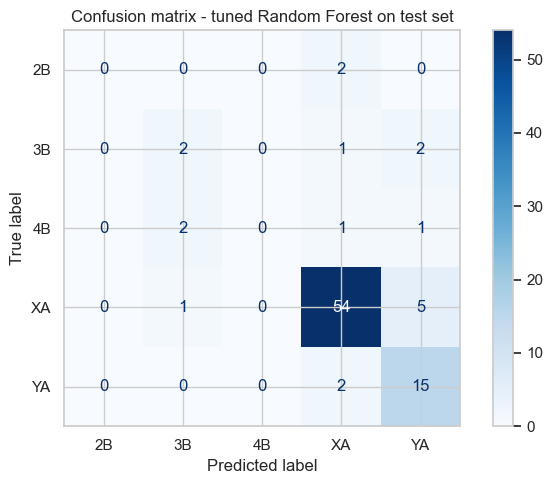

In [16]:
# Run the tuned model on the test set
y_pred_enc = best_rf.predict(X_test_proc)
y_pred = le.inverse_transform(y_pred_enc)
y_true = le.inverse_transform(y_test_enc)

acc = accuracy_score(y_test_enc, y_pred_enc)
f1  = f1_score(y_test_enc, y_pred_enc, average='weighted')

print('Test set accuracy : {:.3f}'.format(acc))
print('Test set F1 (wtd) : {:.3f}'.format(f1))
print()
print('Per-class report:')
print(classification_report(y_true, y_pred, digits=3))

# Confusion matrix
labels = le.classes_
cm = confusion_matrix(y_true, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion matrix - tuned Random Forest on test set')
plt.tight_layout()
plt.show()


## Section 13 - Model Comparison

All three baseline models and the tuned Random Forest are now evaluated on the test set so their final performance can be compared on equal terms. Each model was trained on the full training set and tested on the same 88 specimens.

Two accuracy figures are reported for each model:
- Weighted F1: balances performance across classes weighted by how many specimens each class has. This favours models that are good at XA and YA since those classes are large.
- Macro F1: treats every class equally regardless of size. This is the harder and more honest measure for this dataset, because it penalises a model that ignores small classes like 2B and 4B.

The dataset is small (439 specimens after filtering) and there is no published benchmark for this specific test programme, so this comparison is internal. The results reflect the limits of the available data as much as the limits of the models.

In [17]:
# Train each model on the full training set and evaluate on the test set
all_models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=RANDOM_STATE
    ),
    'SVM': SVC(
        class_weight='balanced', kernel='rbf', probability=True, random_state=RANDOM_STATE
    ),
    'Random Forest (tuned)': best_rf,
}

comparison_rows = []
for name, model in all_models.items():
    if name != 'Random Forest (tuned)':
        model.fit(X_train_proc, y_train_enc)
    preds = model.predict(X_test_proc)
    comparison_rows.append({
        'Model':            name,
        'Test Accuracy':    '{:.3f}'.format(accuracy_score(y_test_enc, preds)),
        'F1 Weighted':      '{:.3f}'.format(f1_score(y_test_enc, preds, average='weighted')),
        'F1 Macro':         '{:.3f}'.format(f1_score(y_test_enc, preds, average='macro')),
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))
print()
print('Note: macro F1 treats all classes equally regardless of size.')
print('      weighted F1 is influenced by the large XA and YA classes.')
print()
print('Hardware context: all models trained on a standard CPU.')
print('Dataset size: 351 training specimens, 88 test specimens, 5 classes.')


                Model Test Accuracy F1 Weighted F1 Macro
  Logistic Regression         0.545       0.613    0.377
        Random Forest         0.795       0.761    0.375
                  SVM         0.682       0.717    0.456
Random Forest (tuned)         0.807       0.781    0.410

Note: macro F1 treats all classes equally regardless of size.
      weighted F1 is influenced by the large XA and YA classes.

Hardware context: all models trained on a standard CPU.
Dataset size: 351 training specimens, 88 test specimens, 5 classes.


## Section 14 - SHAP Interpretability

Knowing that a model is accurate is useful, but knowing why it makes a particular prediction is what makes results trustworthy and actionable in practice. SHAP (SHapley Additive exPlanations) is a method that assigns each feature a score for each prediction, showing how much that feature pushed the prediction toward or away from a particular class.

A positive SHAP value for a feature means that measurement increased the predicted probability of a class. A negative value means it decreased it. The magnitude shows how strong the effect was.

Two plots are produced:
- A bar chart ranking features by their average absolute SHAP value across all specimens and classes. Features at the top had the most influence on predictions overall.
- A beeswarm plot showing the distribution of SHAP values for each feature, coloured by whether the feature value was high (red) or low (blue) for that specimen. This shows not just which features matter but in which direction they push predictions.

shap_array shape: (351, 19, 5)
n_features expected: 19
mean_abs_shap length: 19


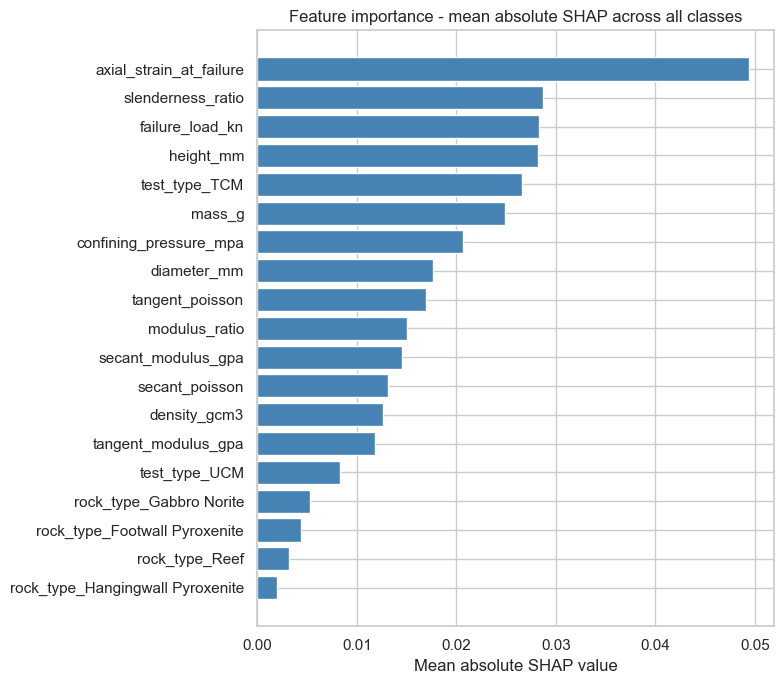

Beeswarm plot: SHAP values for class XA.
Red = high feature value, Blue = low feature value.


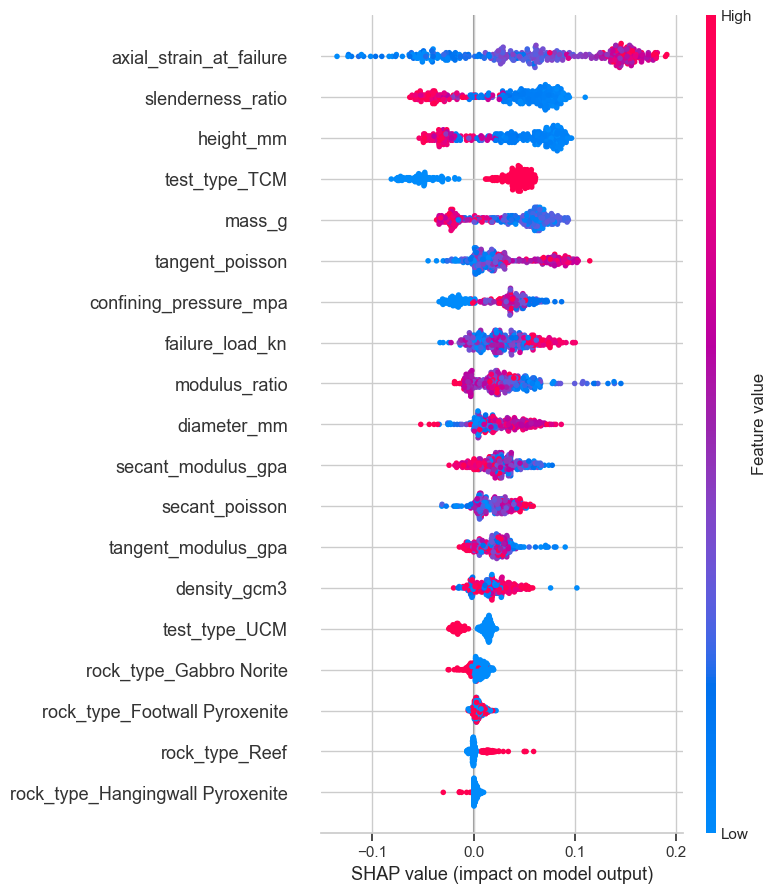

In [19]:
import numpy as np

# Compute SHAP values using TreeExplainer
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_train_proc)

# Handle both old and new SHAP output formats
# Old format: list of arrays (one per class), each shape (n_samples, n_features)
# New format: single 3D array of shape (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_array = np.stack(shap_values, axis=2)
else:
    shap_array = shap_values  # already 3D

print('shap_array shape:', shap_array.shape)
print('n_features expected:', len(all_feature_names))

# Mean absolute SHAP across samples and classes
mean_abs_shap = np.abs(shap_array).mean(axis=(0, 2))
print('mean_abs_shap length:', len(mean_abs_shap))

# Bar chart - overall feature importance by mean absolute SHAP
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(importance_df['feature'], importance_df['mean_abs_shap'], color='steelblue')
ax.set_xlabel('Mean absolute SHAP value')
ax.set_title('Feature importance - mean absolute SHAP across all classes')
plt.tight_layout()
plt.show()

# Beeswarm plot for XA (the dominant class)
# XA is class index 3 in le.classes_
xa_idx = list(le.classes_).index('XA')
xa_shap = shap_array[:, :, xa_idx]
print('Beeswarm plot: SHAP values for class XA.')
print('Red = high feature value, Blue = low feature value.')
shap.summary_plot(
    xa_shap,
    X_train_proc,
    feature_names=all_feature_names,
    plot_type='dot',
    show=True
)


### Observations from SHAP Analysis

**Axial strain at failure is the most influential feature by a clear margin.** This is the amount the specimen compressed before it broke. A high strain at failure pushes the model strongly toward predicting XA, meaning specimens that deform a lot before breaking tend to fail in the XA pattern. This is physically consistent - XA failures involve sliding along a pre-existing plane, which allows more deformation before full fracture than a clean splitting failure.

**Specimen geometry matters as much as the applied load.** Slenderness ratio, height, and failure load are almost equal in importance. Taller, more slender specimens behave differently under load than short, stubby ones - a known effect in rock testing that the model has picked up from the data.

**Test type is the fifth most important feature.** Whether the specimen was tested with or without confining pressure carries independent information beyond what the pressure reading itself provides. This justifies the decision in Section 6 to include test_type as an explicit feature.

**Rock type has very low importance.** The four rock types in this dataset - Footwall Pyroxenite, Gabbro Norite, Hangingwall Pyroxenite, and Reef - do not strongly predict the failure mode on their own. The mechanical measurements carry more information than the rock classification label.